In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
import torchvision.models as models  # Import torchvision models
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
from collections import Counter
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [3]:
# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [5]:
# Define data paths
data_dir = 'Face Expression DataSet/Data'
train_dir = os.path.join(data_dir, 'Training')
test_dir = os.path.join(data_dir, 'testing')


In [7]:
# Define data transformations (ResNet expects 224x224 input)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


In [9]:
# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

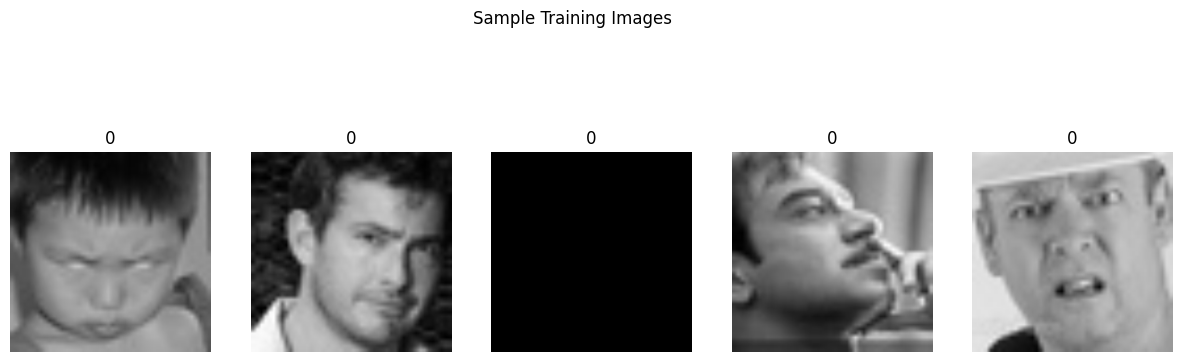

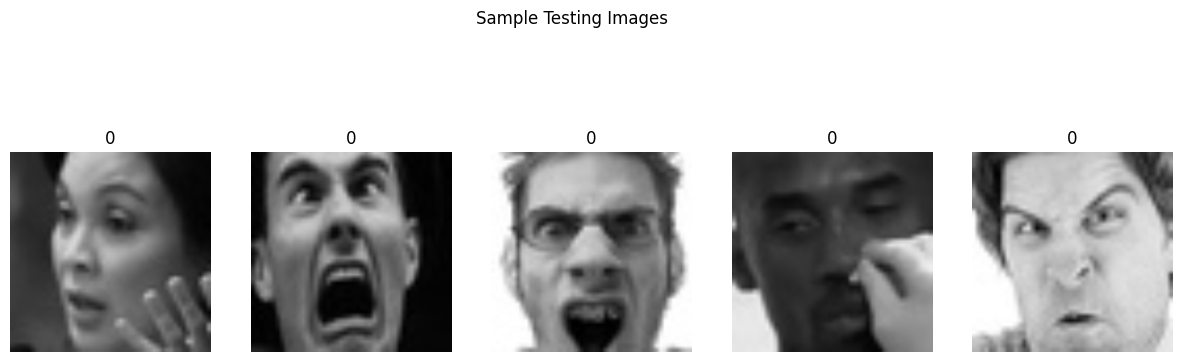

In [11]:
# Display some sample images
def show_sample_images(dataset, title, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        image, label = dataset[i]
        image = image.permute(1, 2, 0).numpy() * 0.5 + 0.5  # Unnormalize
        axes[i].imshow(image)
        axes[i].set_title(train_dataset.classes[label])
        axes[i].axis("off")
    plt.suptitle(title)
    plt.show()

show_sample_images(train_dataset, "Sample Training Images")
show_sample_images(test_dataset, "Sample Testing Images")

In [13]:
# Split dataset into training and validation
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [15]:
# Load ResNet101 Model
model = models.resnet101(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(train_dataset.classes))  # Modify final layer for classification
model = model.to(device)

C:\Users\yashp\anaconda3\envs\FER_TL\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\yashp\anaconda3\envs\FER_TL\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to C:\Users\yashp/.cache\torch\hub\checkpoints\resnet101-63fe2227.pth
100%|██████████| 171M/171M [02:27<00:00, 1.21MB/s] 


In [17]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [19]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)


In [21]:
# Early Stopping Class
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

# Training Loop
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10):
    model.train()
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    early_stopping = EarlyStopping(patience=5)
    
    for epoch in range(epochs):
        running_loss = 0.0
        all_preds, all_labels = [], []
        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            all_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
        
        acc = accuracy_score(all_labels, all_preds)
        history['loss'].append(running_loss / len(train_loader))
        history['accuracy'].append(acc)
        
        # Validation
        model.eval()
        val_loss, val_preds, val_labels = 0.0, [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
        
        val_acc = accuracy_score(val_labels, val_preds)
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_accuracy'].append(val_acc)
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}, Accuracy: {acc:.4f}, Val Loss: {val_loss/len(val_loader):.4f}, Val Accuracy: {val_acc:.4f}")
        
        scheduler.step()
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print("Early stopping triggered.")
            break
    
    return history

In [23]:
# Train the model
history = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=30)

100%|██████████| 320/320 [01:53<00:00,  2.81it/s]


Epoch 1, Loss: 1.2977, Accuracy: 0.5074, Val Loss: 1.1737, Val Accuracy: 0.5637


100%|██████████| 320/320 [01:46<00:00,  3.01it/s]


Epoch 2, Loss: 1.2661, Accuracy: 0.5269, Val Loss: 1.1561, Val Accuracy: 0.5598


100%|██████████| 320/320 [01:46<00:00,  3.01it/s]


...

Epoch 7, Loss: 0.1770, Accuracy: 0.9411, Val Loss: 1.5757, Val Accuracy: 0.6312


100%|██████████| 320/320 [01:46<00:00,  3.01it/s]


Epoch 8, Loss: 0.0912, Accuracy: 0.9699, Val Loss: 1.6745, Val Accuracy: 0.6230


100%|██████████| 320/320 [01:46<00:00,  3.02it/s]


Epoch 9, Loss: 0.0717, Accuracy: 0.9753, Val Loss: 2.1135, Val Accuracy: 0.6176
Early stopping triggered.


In [24]:
# Save Model
torch.save({'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict()}, "resnet101_emotion_recognition.pth")
print("Model saved successfully.")


Model saved successfully.


100%|██████████| 32/32 [00:05<00:00,  6.32it/s]


Accuracy: 0.6221
Precision: 0.6588
Recall: 0.6221
F1-score: 0.6288


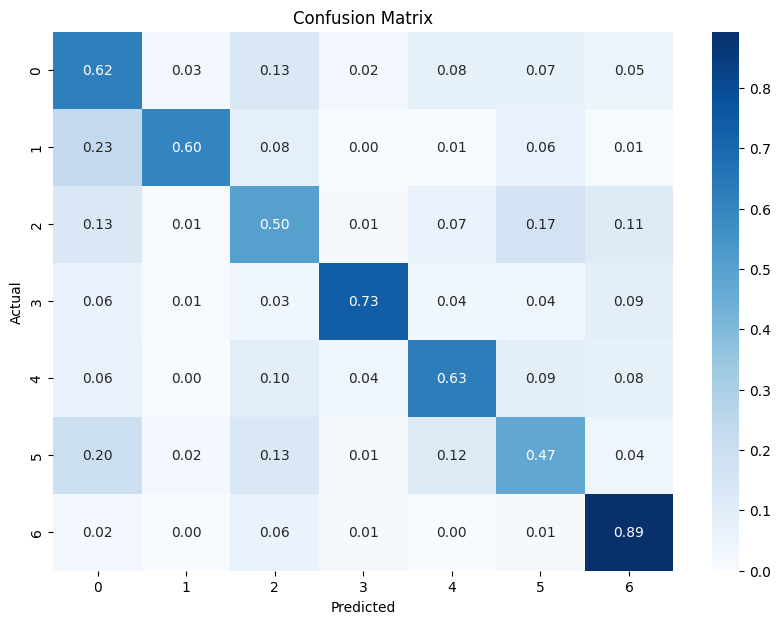

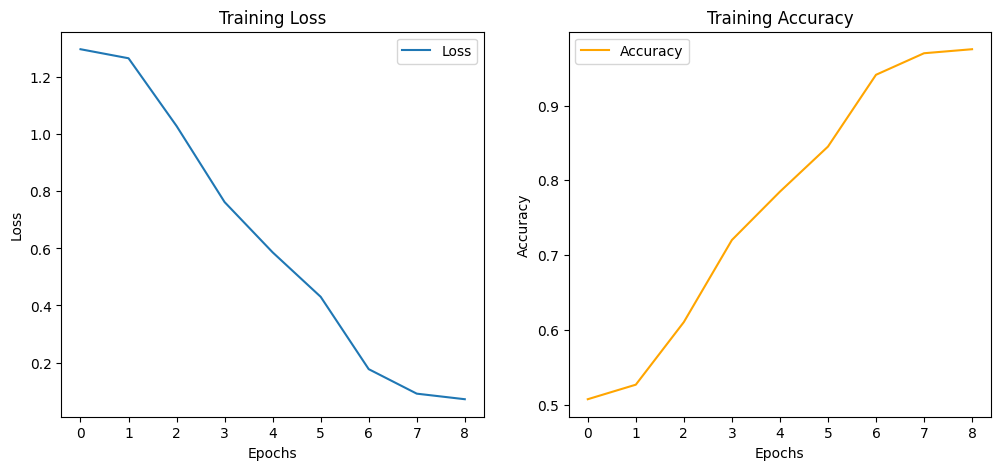

In [25]:
# Evaluation on test set
def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(test_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            all_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

# Evaluate the model
evaluate_model(model, test_loader)

# Plot Accuracy & Loss Graph
def plot_metrics(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Accuracy', color='orange')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training Accuracy')
    plt.legend()
    
    plt.show()

# Plot the metrics
plot_metrics(history)